# Prototype 1

This uses the kaggle dataset being the NJ Transit + Amtrak (NEC) Rail Performance


The baseline pipeline: load → clean → label → features → time split → Logistic Regression → PR-AUC + confusion matrix.


Currently it has only 1 month of data, once I flesh out this prototype I will ad 2 more months making Prototype have 3 months of data to use and analyse.



Depending on the platfrom the file path will always be different.

In [100]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pycparser.c_lexer import keyword

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)


In [101]:
#import dataset and show table
df = pd.read_csv("/content/2018_03.csv")
df.head()


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type
0,2018-03-01,3805,1.0,New York Penn Station,105,New York Penn Station,105,2018-03-02 01:22:00,2018-03-02 01:21:05,0.000000,departed,Northeast Corrdr,NJ Transit
1,2018-03-01,3805,2.0,New York Penn Station,105,Secaucus Upper Lvl,38187,2018-03-02 01:31:00,2018-03-02 01:31:08,0.133333,departed,Northeast Corrdr,NJ Transit
2,2018-03-01,3805,3.0,Secaucus Upper Lvl,38187,Newark Penn Station,107,2018-03-02 01:40:00,2018-03-02 01:40:07,0.116667,departed,Northeast Corrdr,NJ Transit
3,2018-03-01,3805,4.0,Newark Penn Station,107,Newark Airport,37953,2018-03-02 01:45:00,2018-03-02 01:45:10,0.166667,departed,Northeast Corrdr,NJ Transit
4,2018-03-01,3805,5.0,Newark Airport,37953,North Elizabeth,109,2018-03-02 01:49:00,2018-03-02 01:49:10,0.166667,departed,Northeast Corrdr,NJ Transit


In [102]:
#sanity checks
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.info()


Shape: (256508, 13)

Columns:
 ['date', 'train_id', 'stop_sequence', 'from', 'from_id', 'to', 'to_id', 'scheduled_time', 'actual_time', 'delay_minutes', 'status', 'line', 'type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256508 entries, 0 to 256507
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            256508 non-null  object 
 1   train_id        256508 non-null  object 
 2   stop_sequence   243028 non-null  float64
 3   from            256508 non-null  object 
 4   from_id         256508 non-null  int64  
 5   to              256508 non-null  object 
 6   to_id           256508 non-null  int64  
 7   scheduled_time  243028 non-null  object 
 8   actual_time     256508 non-null  object 
 9   delay_minutes   243028 non-null  float64
 10  status          256508 non-null  object 
 11  line            256508 non-null  object 
 12  type            256508 non-null  object 
dtypes: float64(2), 

In [103]:
# Data cleaning  step 4
# Basic cleanup: standardize column names (optional but helps)
df.columns = [c.strip() for c in df.columns]

# Parse date and time columns if present
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

for col in ["scheduled_time", "actual_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


# Ensure delay_minutes is numeric
if "delay_minutes" in df.columns:
    df["delay_minutes"] = pd.to_numeric(df["delay_minutes"], errors="coerce")


# Drop rows missing the essentials
needed = ["date", "delay_minutes"]
df = df.dropna(subset=[c for c in needed if c in df.columns]).copy()


print("After cleaning:", df.shape)
df.head()


After cleaning: (243028, 13)


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type
0,2018-03-01,3805,1.0,New York Penn Station,105,New York Penn Station,105,2018-03-02 01:22:00,2018-03-02 01:21:05,0.000000,departed,Northeast Corrdr,NJ Transit
1,2018-03-01,3805,2.0,New York Penn Station,105,Secaucus Upper Lvl,38187,2018-03-02 01:31:00,2018-03-02 01:31:08,0.133333,departed,Northeast Corrdr,NJ Transit
2,2018-03-01,3805,3.0,Secaucus Upper Lvl,38187,Newark Penn Station,107,2018-03-02 01:40:00,2018-03-02 01:40:07,0.116667,departed,Northeast Corrdr,NJ Transit
3,2018-03-01,3805,4.0,Newark Penn Station,107,Newark Airport,37953,2018-03-02 01:45:00,2018-03-02 01:45:10,0.166667,departed,Northeast Corrdr,NJ Transit
4,2018-03-01,3805,5.0,Newark Airport,37953,North Elizabeth,109,2018-03-02 01:49:00,2018-03-02 01:49:10,0.166667,departed,Northeast Corrdr,NJ Transit


In [104]:
#Using disruption as the binary label


THRESHOLD_MIN = 5

df["disruption"] = (df["delay_minutes"] >= THRESHOLD_MIN).astype(int)

print(df["disruption"].value_counts(dropna=False))
print("Positive rate:", df["disruption"].mean())


disruption
0    193219
1     49809
Name: count, dtype: int64
Positive rate: 0.20495169280905903


In [105]:
#Creating a segment key
# Prefer ID-based segment (stable), fallback to names

if "from_id" in df.columns and "to_id" in df.columns:
    df["segment_id"] = df["from_id"].astype(str) + "->" + df["to_id"].astype(str)
else:
    df["segment_id"] = df["from"].astype(str) + "->" + df["to"].astype(str)

df["segment_id"].head()


,segment_id
0,105->105
1,105->38187
2,38187->107
3,107->37953
4,37953->109


In [106]:
#Including features to the prototype

# Time-based features
df["day_of_week"] = df["date"].dt.dayofweek

if "scheduled_time" in df.columns:
    df["sched_hour"] = df["scheduled_time"].dt.hour
else:
    df["sched_hour"] = 0  # fallback

# Numeric feature
if "stop_sequence" in df.columns:
    df["stop_sequence"] = pd.to_numeric(df["stop_sequence"], errors="coerce").fillna(0)
else:
    df["stop_sequence"] = 0


In [107]:
#Make a modelling table
feature_cols = ["day_of_week", "sched_hour", "stop_sequence"]

cat_cols = []
for c in ["line", "type", "status"]:
    if c in df.columns:
        cat_cols.append(c)

X = df[feature_cols + cat_cols].copy()
y = df["disruption"].copy()

# One-hot encode categoricals (safe for Prototype 1)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
X.head()


X shape: (243028, 15)


,day_of_week,sched_hour,stop_sequence,line_Bergen Co. Line,line_Gladstone Branch,line_Main Line,line_Montclair-Boonton,line_Morristown Line,line_No Jersey Coast,line_Northeast Corrdr,line_Pascack Valley,line_Princeton Shuttle,line_Raritan Valley,status_departed,status_estimated
0,3,1,1.0,False,False,False,False,False,False,True,False,False,False,True,False
1,3,1,2.0,False,False,False,False,False,False,True,False,False,False,True,False
2,3,1,3.0,False,False,False,False,False,False,True,False,False,False,True,False
3,3,1,4.0,False,False,False,False,False,False,True,False,False,False,True,False
4,3,1,5.0,False,False,False,False,False,False,True,False,False,False,True,False


In [108]:
#Time-based split (NO random split)
# Train %70, Test %30
df_sorted = df.sort_values("date").copy()
X_sorted = X.loc[df_sorted.index]
y_sorted = y.loc[df_sorted.index]

split_idx = int(len(df_sorted) * 0.7)

X_train = X_sorted.iloc[:split_idx]
y_train = y_sorted.iloc[:split_idx]

X_test = X_sorted.iloc[split_idx:]
y_test = y_sorted.iloc[split_idx:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train positive rate:", y_train.mean(), "Test positive rate:", y_test.mean())


Train size: (170119, 15) Test size: (72909, 15)
Train positive rate: 0.21395611307378953 Test positive rate: 0.1839416258623764


In [109]:
# Training with LogisticRegression as the baseline
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0      0.872     0.522     0.653     59498
           1      0.237     0.661     0.349     13411

    accuracy                          0.547     72909
   macro avg      0.555     0.591     0.501     72909
weighted avg      0.755     0.547     0.597     72909

Confusion matrix:
 [[31040 28458]
 [ 4550  8861]]


Average Precision (PR-AUC): 0.2513


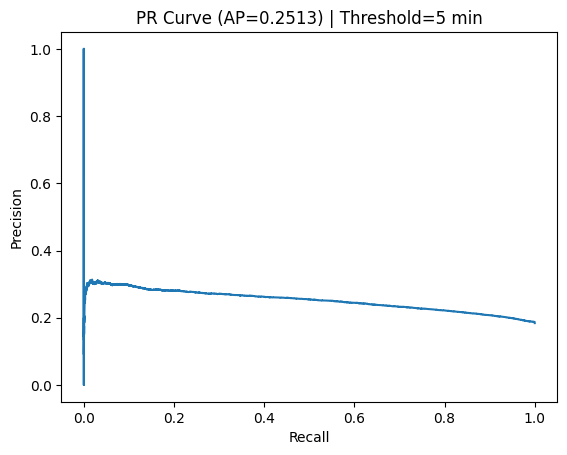

In [110]:
#Other evaluation metrics (PR-AUC + PR curve)
ap = average_precision_score(y_test, y_prob)
print("Average Precision (PR-AUC):", round(ap, 4))

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve (AP={ap:.4f}) | Threshold={THRESHOLD_MIN} min")
plt.show()
